<a href="https://colab.research.google.com/github/saifmukadam10/Q-Learning-/blob/main/Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
import time


In [2]:
num_states = 5
num_actions = 2
q_table = np.zeros((num_states,num_actions))
q_table

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [3]:
env_info = [
    [(0,0), (0,1), (0,2), (0,3),
     (1,3), (2,3), (2,2), (2,1),
     (2,0), (3,0)],

    [(1,0), (1,1), (1,2)]   # cliffs
]

In [4]:
class GridWorldEnvironment:

    def __init__(self, info):

        self.safe_path = info[0]
        self.cliffs = info[1]

        self.start_loc = self.safe_path[0]
        self.trm_loc = self.safe_path[-1]

    def get_state_number(self, loc):
        return 4 * loc[0] + loc[1]

    def env_start(self):

        self.agent_loc = self.start_loc

        state = self.get_state_number(self.agent_loc)

        return state

    def env_step(self, action):

        row, col = self.agent_loc

        # ACTIONS
        # 0 = UP
        # 1 = LEFT
        # 2 = DOWN
        # 3 = RIGHT

        if action == 0:
            next_loc = (row - 1, col)

        elif action == 1:
            next_loc = (row, col - 1)

        elif action == 2:
            next_loc = (row + 1, col)

        elif action == 3:
            next_loc = (row, col + 1)

        # CHECK BOUNDARIES
        if (
            next_loc[0] < 0 or
            next_loc[0] >= 4 or
            next_loc[1] < 0 or
            next_loc[1] >= 4
        ):
            next_loc = self.agent_loc

        self.agent_loc = next_loc

        reward = -1
        terminal = False

        # TERMINAL STATE
        if self.agent_loc == self.trm_loc:
            reward = 100
            terminal = True

        # CLIFF
        elif self.agent_loc in self.cliffs:
            reward = -100
            self.agent_loc = self.start_loc

        state = self.get_state_number(self.agent_loc)

        return reward, state, terminal


In [8]:
# ==========================================
# Q-LEARNING AGENT
# ==========================================

class QLearningAgent:

    def __init__(self,
                 num_actions,
                 num_states,
                 epsilon,
                 learning_rate,
                 discount,
                 seed=0):

        self.num_actions = num_actions
        self.num_states = num_states

        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.discount = discount

        self.rand_generator = np.random.RandomState(seed)

        # Q TABLE
        self.q_table = np.zeros((num_states, num_actions))


         # --------------------------------------

    def argmax(self, q_values):

        top = float("-inf")
        ties = []

        for i in range(len(q_values)):

            if q_values[i] > top:
                top = q_values[i]
                ties = []

            if q_values[i] == top:
                ties.append(i)

        return self.rand_generator.choice(ties)

    # --------------------------------------

    def choose_action(self, state):

        if self.rand_generator.rand() < self.epsilon:
            action = self.rand_generator.randint(self.num_actions)

        else:
            action = self.argmax(self.q_table[state])

        return action

    # --------------------------------------

    def agent_start(self, state):

        action = self.choose_action(state)

        self.prev_state = state
        self.prev_action = action

        return action

    # --------------------------------------

    def agent_step(self, reward, state):

        action = self.choose_action(state)

        # Q-LEARNING UPDATE
        best_next_q = np.max(self.q_table[state])

        current_q = self.q_table[self.prev_state, self.prev_action]

        self.q_table[self.prev_state, self.prev_action] = (
            current_q
            + self.learning_rate *
            (
                reward
                + self.discount * best_next_q
                - current_q
            )
        )

        self.prev_state = state
        self.prev_action = action

        return action

    # --------------------------------------

    def agent_end(self, reward):

        current_q = self.q_table[self.prev_state, self.prev_action]

        self.q_table[self.prev_state, self.prev_action] = (
            current_q
            + self.learning_rate *
            (reward - current_q)
        )

    # --------------------------------------

    def test_action(self, state):

        return self.argmax(self.q_table[state])




In [9]:
# ==========================================
# TRAINING
# ==========================================

env = GridWorldEnvironment(env_info)

agent = QLearningAgent(
    num_actions=4,
    num_states=16,
    epsilon=0.1,
    learning_rate=0.1,
    discount=0.9,
    seed=0
)

episodes = 100

returns = []

for episode in range(episodes):

    total_reward = 0

    state = env.env_start()

    action = agent.agent_start(state)

    while True:

        reward, next_state, terminal = env.env_step(action)

        total_reward += reward

        if terminal:

            agent.agent_end(reward)

            break

        else:

            action = agent.agent_step(reward, next_state)

            state = next_state

    returns.append(total_reward)

    print(f"Episode {episode+1} completed")


# ==========================================
# PRINT Q TABLE
# ==========================================

print("\nTrained Q-Table:\n")
print(agent.q_table)



Episode 1 completed
Episode 2 completed
Episode 3 completed
Episode 4 completed
Episode 5 completed
Episode 6 completed
Episode 7 completed
Episode 8 completed
Episode 9 completed
Episode 10 completed
Episode 11 completed
Episode 12 completed
Episode 13 completed
Episode 14 completed
Episode 15 completed
Episode 16 completed
Episode 17 completed
Episode 18 completed
Episode 19 completed
Episode 20 completed
Episode 21 completed
Episode 22 completed
Episode 23 completed
Episode 24 completed
Episode 25 completed
Episode 26 completed
Episode 27 completed
Episode 28 completed
Episode 29 completed
Episode 30 completed
Episode 31 completed
Episode 32 completed
Episode 33 completed
Episode 34 completed
Episode 35 completed
Episode 36 completed
Episode 37 completed
Episode 38 completed
Episode 39 completed
Episode 40 completed
Episode 41 completed
Episode 42 completed
Episode 43 completed
Episode 44 completed
Episode 45 completed
Episode 46 completed
Episode 47 completed
Episode 48 completed
E

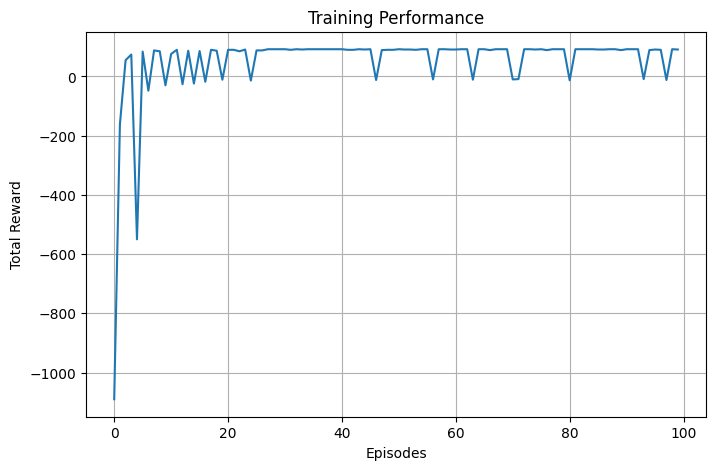

In [10]:
# ==========================================
# PLOT TRAINING REWARDS
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(returns)

plt.title("Training Performance")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")

plt.grid(True)

plt.show()

In [11]:
# ==========================================
# TEST THE TRAINED AGENT
# ==========================================

test_env = GridWorldEnvironment(env_info)

state = test_env.env_start()

chosen_path = [test_env.agent_loc]

total_test_reward = 0

while True:

    action = agent.test_action(state)

    reward, state, terminal = test_env.env_step(action)

    chosen_path.append(test_env.agent_loc)

    total_test_reward += reward

    if terminal:
        break

print("\nTest Reward:", total_test_reward)

print("\nLearned Path:")
print(chosen_path)



Test Reward: 92

Learned Path:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 2), (3, 2), (3, 1), (3, 0)]


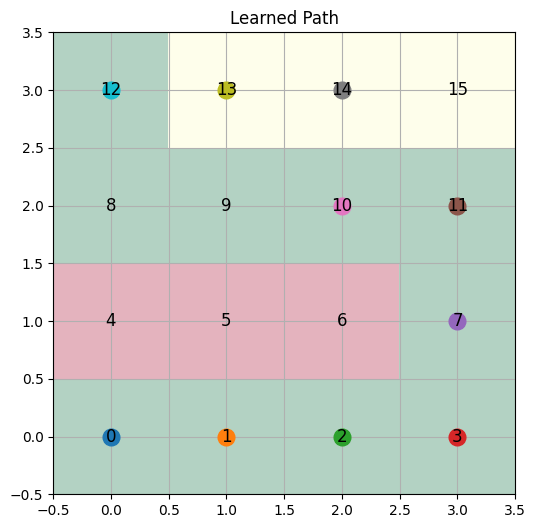

In [12]:
# ==========================================
# VISUALIZE PATH
# ==========================================

grid = np.zeros((4,4))

for i in range(4):
    for j in range(4):

        if (i,j) in env.safe_path:
            grid[i,j] = 1

        elif (i,j) in env.cliffs:
            grid[i,j] = -1

plt.figure(figsize=(6,6))

plt.imshow(grid, cmap='RdYlGn', alpha=0.3)

# STATE NUMBERS
for i in range(4):
    for j in range(4):
        plt.text(j, i, str(i*4+j),
                 ha='center',
                 va='center',
                 fontsize=12)

# PLOT PATH
for loc in chosen_path:

    plt.plot(
        loc[1],
        loc[0],
        marker='o',
        markersize=12
    )

plt.title("Learned Path")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()